In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# CELL 1 — Install dependencies
# ═══════════════════════════════════════════════════════════════════════════════
!pip install monai nibabel -q


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Clone M3D-NCA repo
# ═══════════════════════════════════════════════════════════════════════════════
import shutil, os

if os.path.exists('/kaggle/working/M3D-NCA'):
    shutil.rmtree('/kaggle/working/M3D-NCA')

!git clone https://github.com/MECLabTUDA/M3D-NCA.git /kaggle/working/M3D-NCA
!pip install -r /kaggle/working/M3D-NCA/requirements.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 27.1 MB/s eta 0:00:0000:010:01
Cloning into '/kaggle/working/M3D-NCA'...
remote: Enumerating objects: 368, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 368 (delta 13), reused 13 (delta 13), pack-reused 352 (from 1)
Receiving objects: 100% (368/368), 32.03 MiB | 29.79 MiB/s, done.
Resolving deltas: 100% (125/125), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.6/169.6 kB 5.3 MB/s eta 0:00:00


In [2]:

import os

for path in [
    '/kaggle/working/M3D-NCA/src/__init__.py',
    '/kaggle/working/M3D-NCA/src/data/__init__.py',
    '/kaggle/working/M3D-NCA/src/losses/__init__.py',
    '/kaggle/working/M3D-NCA/src/agents/__init__.py',
    '/kaggle/working/M3D-NCA/src/models/__init__.py',
]:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    open(path, 'a').close()
    print(f"OK: {path}")

OK: /kaggle/working/M3D-NCA/src/__init__.py
OK: /kaggle/working/M3D-NCA/src/data/__init__.py
OK: /kaggle/working/M3D-NCA/src/losses/__init__.py
OK: /kaggle/working/M3D-NCA/src/agents/__init__.py
OK: /kaggle/working/M3D-NCA/src/models/__init__.py


In [5]:
import os
 
dataloader_code = r'''import os
import numpy as np
import nibabel as nib
import torch
from torch.utils.data import Dataset
 
 
def find_all_patients(base):
    patients = []
 
    def has_nii(path):
        try:
            return any(f.endswith(".nii") or f.endswith(".nii.gz") for f in os.listdir(path))
        except Exception:
            return False
 
    def get_subdirs(path):
        try:
            return sorted([os.path.join(path, e) for e in os.listdir(path)
                           if os.path.isdir(os.path.join(path, e))])
        except Exception:
            return []
 
    for d1 in get_subdirs(base):
        if has_nii(d1):
            patients.append(d1)
        else:
            for d2 in get_subdirs(d1):
                if has_nii(d2):
                    patients.append(d2)
                else:
                    for d3 in get_subdirs(d2):
                        if has_nii(d3):
                            patients.append(d3)
 
    print(f"[find_all_patients] Found {len(patients)} patient folders")
    if patients:
        print(f"  Example : {patients[0]}")
        print(f"  Files   : {sorted(os.listdir(patients[0]))}")
    return sorted(patients)
 
 
def augment_volume(img, label, augment=True):
    """
    Better augmentations applied jointly to image (4,H,W,D) and label (3,H,W,D).
 
    Augmentations:
      - Random flips on all 3 axes
      - Random 90-degree axial rotation
      - Gaussian noise (image only)
      - Random intensity scale  [0.9, 1.1]  (image only, per-modality)
      - Random intensity shift  [-0.1, 0.1] (image only, per-modality)
      - Random gamma correction [0.8, 1.2]  (image only, per-modality)
    """
    if not augment:
        return img, label
 
    rng = np.random.default_rng()
 
    # Spatial flips
    for axis in [1, 2, 3]:
        if rng.random() < 0.5:
            img   = np.flip(img,   axis=axis).copy()
            label = np.flip(label, axis=axis).copy()
 
    # Random 90 deg axial rotation
    if rng.random() < 0.5:
        k     = rng.integers(1, 4)
        img   = np.rot90(img,   k, axes=(1, 2)).copy()
        label = np.rot90(label, k, axes=(1, 2)).copy()
 
    # Per-modality intensity augmentations
    for c in range(img.shape[0]):
        if rng.random() < 0.3:
            img[c] += rng.normal(0, 0.05, img[c].shape).astype(np.float32)
        if rng.random() < 0.5:
            img[c] *= rng.uniform(0.9, 1.1)
        if rng.random() < 0.5:
            img[c] += rng.uniform(-0.1, 0.1)
        if rng.random() < 0.3:
            gamma  = rng.uniform(0.8, 1.2)
            mask_p = img[c] > 0
            if mask_p.any():
                mn, mx = img[c][mask_p].min(), img[c][mask_p].max()
                rng_v  = mx - mn + 1e-8
                normed = np.clip((img[c] - mn) / rng_v, 0, 1)
                img[c] = (normed ** gamma) * rng_v + mn
 
    return img, label
 class BraTSDataset(Dataset):
    def __init__(self, patient_dirs, target_size=(96, 96, 16), augment=False):
        self.patient_dirs = patient_dirs
        self.target_size  = target_size
        self.augment      = augment
        print(f"Dataset ready: {len(self.patient_dirs)} patients, "
              f"target_size={target_size}, augment={augment}")
 
    def __len__(self):
        return len(self.patient_dirs)
 
    def _find_file(self, folder, keywords):
        files = os.listdir(folder)
        for kw in keywords:
            for f in files:
                name = f.lower()
                if kw.lower() in name and (name.endswith(".nii") or name.endswith(".nii.gz")):
                    return os.path.join(folder, f)
        raise FileNotFoundError(f"No file matching {keywords} in {folder}\nFiles: {sorted(files)}")
 
    def __getitem__(self, idx):
        d = self.patient_dirs[idx]
 
        t1    = nib.load(self._find_file(d, ["-t1n", "_t1n", "_t1."])).get_fdata(dtype=np.float32)
        t1ce  = nib.load(self._find_file(d, ["-t1c", "_t1c", "t1ce"])).get_fdata(dtype=np.float32)
        t2    = nib.load(self._find_file(d, ["-t2w", "_t2w", "_t2."])).get_fdata(dtype=np.float32)
        flair = nib.load(self._find_file(d, ["-t2f", "_t2f", "flair"])).get_fdata(dtype=np.float32)
        seg   = nib.load(self._find_file(d, ["-seg", "_seg"])).get_fdata(dtype=np.float32)
 
        img = np.stack([t1, t1ce, t2, flair], axis=0)
 
        for c in range(4):
            mask = img[c] > 0
            if mask.sum() > 0:
                img[c][mask] = (img[c][mask] - img[c][mask].mean()) / (img[c][mask].std() + 1e-8)
            img[c][~mask] = 0.0
 
        et_val = 4 if np.any(seg == 4) else 3
        wt     = (seg > 0).astype(np.float32)
        tc     = ((seg == 1) | (seg == et_val)).astype(np.float32)
        et     = (seg == et_val).astype(np.float32)
        label  = np.stack([wt, tc, et], axis=0)
 
        img   = self._center_crop_pad(img,   self.target_size)
        label = self._center_crop_pad(label, self.target_size)
 
        img, label = augment_volume(img, label, augment=self.augment)
 
        return torch.tensor(img.copy()), torch.tensor(label.copy())
 
    def _center_crop_pad(self, arr, size):
        _, h, w, d = arr.shape
        sh = max(0, (h - size[0]) // 2)
        sw = max(0, (w - size[1]) // 2)
        sd = max(0, (d - size[2]) // 2)
        arr = arr[:, sh:sh+size[0], sw:sw+size[1], sd:sd+size[2]]
        _, ch, cw, cd = arr.shape
        pad = [(0,0),(0,max(0,size[0]-ch)),(0,max(0,size[1]-cw)),(0,max(0,size[2]-cd))]
        return np.pad(arr, pad, mode="constant", constant_values=0)
'''
 
path = '/kaggle/working/M3D-NCA/src/data/BraTSDataLoader.py'
os.makedirs(os.path.dirname(path), exist_ok=True)
with open(path, 'w') as f:
    f.write(dataloader_code)
 
with open(path) as f:
    txt = f.read()
assert 'find_all_patients' in txt
assert 'BraTSDataset'      in txt
assert 'augment_volume'    in txt
print("Written and verified OK:", path)
 

Written and verified OK: /kaggle/working/M3D-NCA/src/data/BraTSDataLoader.py


In [6]:
import os
 
model_path = '/kaggle/working/M3D-NCA/src/models/Model_BasicNCA3D.py'
 
patched = r'''import torch
import torch.nn as nn
import torch.nn.functional as F
 
 
class BasicNCA3D(nn.Module):
    """
    3-D Neural Cellular Automaton — enhanced version.
 
    CAPACITY
      hidden_size default 256 (was 128).
      Two-layer MLP: fc0->BN->ReLU->fc_mid->BN->ReLU->fc1.
 
    LARGER RECEPTIVE FIELD
      p0: depthwise Conv3d, kernel=7, local context.
      p1: dilated depthwise Conv3d, kernel=3, dilation=2, eff. field=5.
      Both concatenated with self: perceive_dim = channel_n * 3.
 
    ARCHITECTURE LIMITS
      channel_n is permanently tied to D (depth axis) via transpose(1,4).
      Dilation > 2 causes artefacts on D=16; keep <= 2.
      Very long-range features still require many NCA steps.
    """
 
    def __init__(self, channel_n, fire_rate, device, hidden_size=256,
                 input_channels=1, init_method="standard",
                 kernel_size=7, groups=False):
        super(BasicNCA3D, self).__init__()
        self.device         = device
        self.channel_n      = channel_n
        self.input_channels = input_channels
 
        # Depthwise local conv  (p0)
        padding_p0 = (kernel_size - 1) // 2
        self.p0 = nn.Conv3d(
            channel_n, channel_n,
            kernel_size=kernel_size, stride=1,
            padding=padding_p0, padding_mode="reflect",
            groups=channel_n,
        )
 
        # Dilated depthwise conv  (p1) — larger receptive field
        # kernel=3, dilation=2  =>  effective receptive field = 5
        # padding=dilation keeps spatial size unchanged
        dilation = 2
        self.p1 = nn.Conv3d(
            channel_n, channel_n,
            kernel_size=3, stride=1,
            padding=dilation, dilation=dilation,
            padding_mode="reflect",
            groups=channel_n,
        )
 
        # MLP: self + p0 + p1 -> hidden -> hidden -> channel_n
        perceive_dim = channel_n * 3
        self.fc0    = nn.Linear(perceive_dim, hidden_size)
        self.fc_mid = nn.Linear(hidden_size,  hidden_size)
        self.fc1    = nn.Linear(hidden_size,  channel_n, bias=False)
 
        self.bn0 = nn.BatchNorm3d(hidden_size, track_running_stats=False)
        self.bn1 = nn.BatchNorm3d(hidden_size, track_running_stats=False)
 
        with torch.no_grad():
            self.fc1.weight.zero_()
 
        if init_method == "xavier":
            nn.init.xavier_uniform_(self.fc0.weight)
            nn.init.xavier_uniform_(self.fc_mid.weight)
            nn.init.xavier_uniform_(self.fc1.weight)
 
        self.fire_rate = fire_rate
        self.to(self.device)
 
    def perceive(self, x):
        y0 = self.p0(x)
        y1 = self.p1(x)
        return torch.cat((x, y0, y1), dim=1)   # (B, channel_n*3, ...)
 
    def update(self, x_in, fire_rate):
        x  = x_in.transpose(1, 4)
        dx = self.perceive(x)
        dx = dx.transpose(1, 4)
 
        # Layer 1
        dx = self.fc0(dx)
        dx = dx.transpose(1, 4)
        dx = self.bn0(dx)
        dx = dx.transpose(1, 4)
        dx = F.relu(dx)
 
        # Layer 2 (more capacity)
        dx = self.fc_mid(dx)
        dx = dx.transpose(1, 4)
        dx = self.bn1(dx)
        dx = dx.transpose(1, 4)
        dx = F.relu(dx)
 
        # Output
        dx = self.fc1(dx)
 
        if fire_rate is None:
            fire_rate = self.fire_rate
 
        stochastic = (
            torch.rand([dx.size(0), dx.size(1), dx.size(2), dx.size(3), 1],
                       device=x_in.device) > fire_rate
        ).float()
        dx = dx * stochastic
 
        x = x_in.transpose(1, 4) + dx.transpose(1, 4)
        return x.transpose(1, 4)
 
    def forward(self, x, steps=10, fire_rate=0.5):
        for _ in range(steps):
            x2 = self.update(x, fire_rate).clone()
            x  = torch.cat(
                (x[..., :self.input_channels],
                 x2[..., self.input_channels:]),
                dim=4,
            )
        return x
'''
 
os.makedirs(os.path.dirname(model_path), exist_ok=True)
with open(model_path, 'w') as f:
    f.write(patched)
 
with open(model_path) as f:
    txt = f.read()
assert 'groups=channel_n' in txt
assert 'fc_mid'           in txt
assert 'self.p1'          in txt
print("Model patched and verified OK:", model_path)
 
 

Model patched and verified OK: /kaggle/working/M3D-NCA/src/models/Model_BasicNCA3D.py


In [7]:
import os
 
loss_code = r'''import torch
import torch.nn as nn
import torch.nn.functional as F
 
class BraTSDiceFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
 
    def _dice(self, prob, target, smooth=1e-6):
        inter = (prob * target).sum(dim=(1, 2, 3))
        union = prob.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
        return (1 - (2 * inter + smooth) / (union + smooth)).mean()
 
    def _focal(self, logit, target):
        bce = F.binary_cross_entropy_with_logits(logit, target, reduction="none")
        pt  = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()
 
    def forward(self, pred_logits, target):
        loss = 0.0
        for c in range(pred_logits.shape[1]):
            prob = torch.sigmoid(pred_logits[:, c])
            loss += self._dice(prob,               target[:, c])
            loss += self._focal(pred_logits[:, c], target[:, c])
        return loss / pred_logits.shape[1]
'''
 
path = '/kaggle/working/M3D-NCA/src/losses/BraTSLoss.py'
os.makedirs(os.path.dirname(path), exist_ok=True)
with open(path, 'w') as f:
    f.write(loss_code)
 
with open(path) as f:
    txt = f.read()
assert 'BraTSDiceFocalLoss' in txt
print("Written and verified OK:", path)
 
 
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Training
#   ✓ CosineAnnealingLR  eta_min=1e-5
#   ✓ Dynamic NCA steps  epoch<20→8, epoch<40→12, else→16
#   ✓ HIDDEN=256  (more capacity)
#   ✓ augment=True on train set
#   ✓ Larger receptive field via dilated p1 in model
# ═══════════════════════════════════════════════════════════════════════════════
import os, sys, time, glob, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
 
sys.path.insert(0, '/kaggle/working/M3D-NCA')
from src.models.Model_BasicNCA3D import BasicNCA3D
from src.losses.BraTSLoss        import BraTSDiceFocalLoss
 
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count()
for i in range(n_gpus):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}"
          f"  {torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB")
 
# ── Hyper-parameters ──────────────────────────────────────────────────
TARGET    = (96, 96, 16)
CHANNEL_N = TARGET[2]      # = 16  — tied to depth axis (architecture limit)
INPUT_CH  = 4
OUTPUT_CH = 3
BATCH     = 2
LR        = 3e-4
EPOCHS    = 60             # more epochs to exploit curriculum steps
FIRE_RATE = 0.5
HIDDEN    = 256            # more capacity (was 128)
VAL_SPLIT = 0.2
 
DATA_ROOT = '/kaggle/input/datasets/nguyenthanhkhanh/brats2024-small-dataset/BraTS2024_small_dataset'
 
print(f"\nTARGET={TARGET}  CHANNEL_N={CHANNEL_N}  HIDDEN={HIDDEN}  BATCH={BATCH}")
 
 

Written and verified OK: /kaggle/working/M3D-NCA/src/losses/BraTSLoss.py
  GPU 0: Tesla T4  15.6 GB
  GPU 1: Tesla T4  15.6 GB

TARGET=(96, 96, 16)  CHANNEL_N=16  HIDDEN=256  BATCH=2


In [9]:
def find_all_patients(root):
    patients = sorted([p for p in glob.glob(os.path.join(root, 'BraTS*'))
                       if os.path.isdir(p)])
    print(f"[find_all_patients] Found {len(patients)} patient folders")
    if patients:
        print(f"  Example : {patients[0]}")
        print(f"  Files   : {sorted(os.listdir(patients[0]))}")
    return patients
 
 
def load_patient(folder, target_size):
    base = os.path.basename(folder)
    mods = ['t1c', 't1n', 't2f', 't2w']
    imgs = []
    for m in mods:
        f = os.path.join(folder, f"{base}-{m}.nii")
        if not os.path.exists(f):
            f += '.gz'
        vol = nib.load(f).get_fdata(dtype=np.float32)
        p1, p99 = np.percentile(vol[vol > 0], [1, 99]) if vol.max() > 0 else (0, 1)
        vol = np.clip(vol, p1, p99)
        vol = (vol - p1) / (p99 - p1 + 1e-8)
        imgs.append(vol)
 
    seg_f = os.path.join(folder, f"{base}-seg.nii")
    if not os.path.exists(seg_f):
        seg_f += '.gz'
    seg = nib.load(seg_f).get_fdata(dtype=np.float32)
 
    def crop_pad(arr, tgt):
        result = np.zeros(tgt, dtype=np.float32)
        slices_src, slices_dst = [], []
        for s, t in zip(arr.shape, tgt):
            start = max(0, (s - t) // 2)
            end   = start + min(s, t)
            slices_src.append(slice(start, end))
            d_start = max(0, (t - s) // 2)
            slices_dst.append(slice(d_start, d_start + (end - start)))
        result[tuple(slices_dst)] = arr[tuple(slices_src)]
        return result
 
    imgs_c = np.stack([crop_pad(v, target_size) for v in imgs], axis=0)
    seg_c  = crop_pad(seg, target_size)
    wt = (seg_c > 0).astype(np.float32)
    tc = np.isin(seg_c, [1, 3]).astype(np.float32)
    et = (seg_c == 3).astype(np.float32)
    return imgs_c, np.stack([wt, tc, et], axis=0)
 
 
def augment_volume(img, label):
    rng = np.random.default_rng()
    for axis in [1, 2, 3]:
        if rng.random() < 0.5:
            img   = np.flip(img,   axis=axis).copy()
            label = np.flip(label, axis=axis).copy()
    if rng.random() < 0.5:
        k     = rng.integers(1, 4)
        img   = np.rot90(img,   k, axes=(1, 2)).copy()
        label = np.rot90(label, k, axes=(1, 2)).copy()
    for c in range(img.shape[0]):
        if rng.random() < 0.3:
            img[c] += rng.normal(0, 0.05, img[c].shape).astype(np.float32)
        if rng.random() < 0.5:
            img[c] *= rng.uniform(0.9, 1.1)
        if rng.random() < 0.5:
            img[c] += rng.uniform(-0.1, 0.1)
        if rng.random() < 0.3:
            gamma  = rng.uniform(0.8, 1.2)
            mask_p = img[c] > 0
            if mask_p.any():
                mn, mx = img[c][mask_p].min(), img[c][mask_p].max()
                rng_v  = mx - mn + 1e-8
                normed = np.clip((img[c] - mn) / rng_v, 0, 1)
                img[c] = (normed ** gamma) * rng_v + mn
    return img, label
 

In [10]:
class BraTSDataset(Dataset):
    def __init__(self, patient_folders, target_size, cache=True, augment=False):
        self.folders     = patient_folders
        self.target_size = target_size
        self.augment     = augment
        self.cache       = {}
        print(f"Dataset ready: {len(patient_folders)} patients, "
              f"target_size={target_size}, augment={augment}")
        if cache:
            print(f"  Caching {len(patient_folders)} patients into RAM...")
            t0 = time.time()
            for i, f in enumerate(patient_folders):
                self.cache[i] = load_patient(f, target_size)
                if (i + 1) % 40 == 0:
                    ela = time.time() - t0
                    eta = ela / (i+1) * (len(patient_folders) - i - 1)
                    print(f"    {i+1}/{len(patient_folders)}  {ela:.0f}s  ETA {eta:.0f}s")
            print(f"  Cache done in {time.time()-t0:.1f}s")
 
    def __len__(self):
        return len(self.folders)
 
    def __getitem__(self, idx):
        if idx in self.cache:
            imgs, mask = self.cache[idx]
            imgs, mask = imgs.copy(), mask.copy()
        else:
            imgs, mask = load_patient(self.folders[idx], self.target_size)
        if self.augment:
            imgs, mask = augment_volume(imgs, mask)
        return torch.from_numpy(imgs), torch.from_numpy(mask)
 
 
# ── Build model ───────────────────────────────────────────────────────
model = BasicNCA3D(
    channel_n      = CHANNEL_N,   # 16 — tied to depth axis
    fire_rate      = FIRE_RATE,
    device         = device,
    hidden_size    = HIDDEN,      # 256 — more capacity
    input_channels = INPUT_CH,
    kernel_size    = 7,           # p0 local; p1 dilated inside model
)
 
_m = nn.DataParallel(model) if n_gpus > 1 else model
_m = _m.to(device)
 
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
 
# Sanity check
print("\n--- Sanity check ---")
_s = torch.zeros(BATCH, *TARGET, CHANNEL_N, device=device)
_s[:, :, :, :, :INPUT_CH] = torch.randn(BATCH, *TARGET, INPUT_CH, device=device)
with torch.amp.autocast('cuda'):
    _o = _m(_s, steps=2, fire_rate=0.5)
print(f"PASSED  input={tuple(_s.shape)}  output={tuple(_o.shape)}")
for i in range(n_gpus):
    print(f"  GPU {i}: {torch.cuda.memory_allocated(i)/1e9:.2f} GB allocated")
 
 
# ── Data ──────────────────────────────────────────────────────────────
all_patients = find_all_patients(DATA_ROOT)
random.shuffle(all_patients)
split          = int(len(all_patients) * (1 - VAL_SPLIT))
train_patients = all_patients[:split]
val_patients   = all_patients[split:]
print(f"Train: {len(train_patients)}  Val: {len(val_patients)}")
 
train_dataset = BraTSDataset(train_patients, TARGET, cache=True, augment=True)
val_dataset   = BraTSDataset(val_patients,   TARGET, cache=True, augment=False)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")
 
 
# ── Loss / Optimiser / Scheduler ─────────────────────────────────────
criterion = BraTSDiceFocalLoss(alpha=0.25, gamma=2.0).to(device)
optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
 
# CosineAnnealingLR with eta_min=1e-5  ← updated
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = EPOCHS,
    eta_min = 1e-5,
)
 
scaler        = torch.amp.GradScaler('cuda')
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [],
           'dice_wt': [], 'dice_tc': [], 'dice_et': [], 'nca_steps': []}
 
 
# ── Helpers ───────────────────────────────────────────────────────────
def state_from_batch(imgs):
    B = imgs.shape[0]
    s = torch.zeros(B, *TARGET, CHANNEL_N, device=imgs.device)
    s[:, :, :, :, :INPUT_CH] = imgs.permute(0, 2, 3, 4, 1)
    return s
 
def extract_logits(x_out):
    return x_out[:, :, :, :, INPUT_CH:INPUT_CH+OUTPUT_CH].permute(0, 4, 1, 2, 3)
 
def dice_per_class(logits, masks):
    probs    = torch.sigmoid(logits.float())
    pred_bin = (probs > 0.5).float()
    scores   = []
    for c in range(OUTPUT_CH):
        inter = (pred_bin[:, c] * masks[:, c]).sum().item()
        denom = pred_bin[:, c].sum().item() + masks[:, c].sum().item()
        scores.append((2 * inter / denom) if denom > 0 else 1.0)
    return scores
 
def get_nca_steps(epoch):
    """
    Curriculum NCA step schedule:
      epoch  < 20  →  8  steps  (fast / rough)
      epoch  < 40  → 12  steps  (medium)
      epoch >= 40  → 16  steps  (full refinement)
    """
    if epoch < 20:
        return 8
    elif epoch < 40:
        return 12
    else:
        return 16
 
 

Trainable parameters: 89,408

--- Sanity check ---
PASSED  input=(2, 96, 96, 16, 16)  output=(2, 96, 96, 16, 16)
  GPU 0: 1.02 GB allocated
  GPU 1: 0.98 GB allocated
[find_all_patients] Found 200 patient folders
  Example : /kaggle/input/datasets/nguyenthanhkhanh/brats2024-small-dataset/BraTS2024_small_dataset/BraTS-GLI-02062-100
  Files   : ['BraTS-GLI-02062-100-seg.nii', 'BraTS-GLI-02062-100-t1c.nii', 'BraTS-GLI-02062-100-t1n.nii', 'BraTS-GLI-02062-100-t2f.nii', 'BraTS-GLI-02062-100-t2w.nii']
Train: 160  Val: 40
Dataset ready: 160 patients, target_size=(96, 96, 16), augment=True
  Caching 160 patients into RAM...
    40/160  134s  ETA 401s
    80/160  274s  ETA 274s
    120/160  406s  ETA 135s
    160/160  552s  ETA 0s
  Cache done in 552.3s
Dataset ready: 40 patients, target_size=(96, 96, 16), augment=False
  Caching 40 patients into RAM...
    40/40  141s  ETA 0s
  Cache done in 140.6s
Train batches: 80  Val batches: 20


In [11]:
print(f"{'Epoch':>6} | {'Steps':>5} | {'Train':>8} | {'Val':>8} | "
      f"{'WT':>6} | {'TC':>6} | {'ET':>6} | {'LR':>8} | Time")
print("-" * 80)
 
for epoch in range(1, EPOCHS + 1):
 
    nca_steps = get_nca_steps(epoch)   # ← dynamic steps
 
    # Train
    model.train()
    train_loss = 0.0
    t0 = time.time()
 
    for imgs, masks in train_loader:
        imgs  = imgs.to(device,  non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
 
        with torch.amp.autocast('cuda'):
            s      = state_from_batch(imgs)
            x_out  = _m(s, steps=nca_steps, fire_rate=FIRE_RATE)
            logits = extract_logits(x_out)
            loss   = criterion(logits, masks)
 
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
 
    train_loss /= len(train_loader)
    scheduler.step()
 
    # Validation
    model.eval()
    val_loss = 0.0
    batch_wt, batch_tc, batch_et = [], [], []
 
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device,  non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                s      = state_from_batch(imgs)
                x_out  = _m(s, steps=nca_steps, fire_rate=FIRE_RATE)
                logits = extract_logits(x_out)
                loss   = criterion(logits, masks)
            val_loss += loss.item()
            wt, tc, et = dice_per_class(logits, masks)
            batch_wt.append(wt); batch_tc.append(tc); batch_et.append(et)
 
    val_loss /= len(val_loader)
    mean_wt   = np.mean(batch_wt)
    mean_tc   = np.mean(batch_tc)
    mean_et   = np.mean(batch_et)
    elapsed   = time.time() - t0
 
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['dice_wt'].append(mean_wt)
    history['dice_tc'].append(mean_tc)
    history['dice_et'].append(mean_et)
    history['nca_steps'].append(nca_steps)
 
    print(f"{epoch:6d} | {nca_steps:5d} | {train_loss:8.4f} | {val_loss:8.4f} | "
          f"{mean_wt:6.3f} | {mean_tc:6.3f} | {mean_et:6.3f} | "
          f"{scheduler.get_last_lr()[0]:8.2e} | {elapsed:.0f}s")
 
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss'   : val_loss,
            'dice_wt'    : mean_wt,
            'dice_tc'    : mean_tc,
            'dice_et'    : mean_et,
            'config': {
                'channel_n'      : CHANNEL_N,
                'hidden_size'    : HIDDEN,
                'input_channels' : INPUT_CH,
                'target'         : TARGET,
            },
        }, '/kaggle/working/best_model.pt')
        print(f"         ✓ Best  WT={mean_wt:.3f} TC={mean_tc:.3f} ET={mean_et:.3f}")
 
print(f"\nDone. Best val loss: {best_val_loss:.4f}")
 
 
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Final verification
# ═══════════════════════════════════════════════════════════════════════════════
with open('/kaggle/working/M3D-NCA/src/models/Model_BasicNCA3D.py') as f:
    txt = f.read()
assert 'groups=channel_n' in txt, "groups=channel_n missing"
assert 'fc_mid'           in txt, "fc_mid missing"
assert 'self.p1'          in txt, "dilated p1 missing"
print("All assertions passed — model patched and verified OK")
 

 Epoch | Steps |    Train |      Val |     WT |     TC |     ET |       LR | Time
--------------------------------------------------------------------------------
     1 |     8 |   0.8616 |   0.7824 |  0.658 |  0.149 |  0.152 | 3.00e-04 | 146s
         ✓ Best  WT=0.658 TC=0.149 ET=0.152
     2 |     8 |   0.7683 |   0.7192 |  0.671 |  0.377 |  0.383 | 2.99e-04 | 145s
         ✓ Best  WT=0.671 TC=0.377 ET=0.383
     3 |     8 |   0.7277 |   0.6911 |  0.716 |  0.330 |  0.346 | 2.98e-04 | 145s
         ✓ Best  WT=0.716 TC=0.330 ET=0.346
     4 |     8 |   0.7074 |   0.6732 |  0.712 |  0.419 |  0.428 | 2.97e-04 | 145s
         ✓ Best  WT=0.712 TC=0.419 ET=0.428
     5 |     8 |   0.6992 |   0.6568 |  0.743 |  0.417 |  0.428 | 2.95e-04 | 145s
         ✓ Best  WT=0.743 TC=0.417 ET=0.428
     6 |     8 |   0.6937 |   0.6374 |  0.778 |  0.476 |  0.479 | 2.93e-04 | 145s
         ✓ Best  WT=0.778 TC=0.476 ET=0.479
     7 |     8 |   0.6831 |   0.6371 |  0.770 |  0.450 |  0.456 | 2.90e-04 | 145s

Visualization setup ready.
Plots will be saved to: /kaggle/working/plots


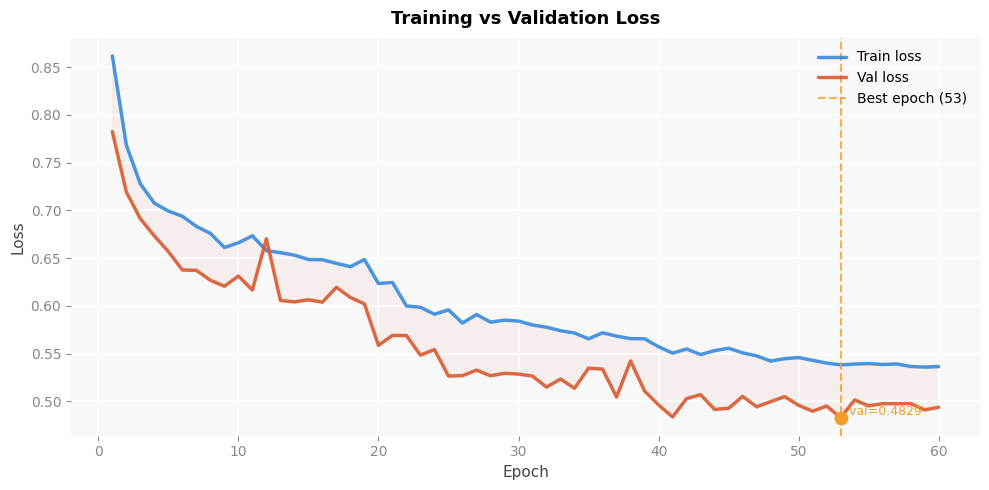

Saved: /kaggle/working/plots/loss_curve.png


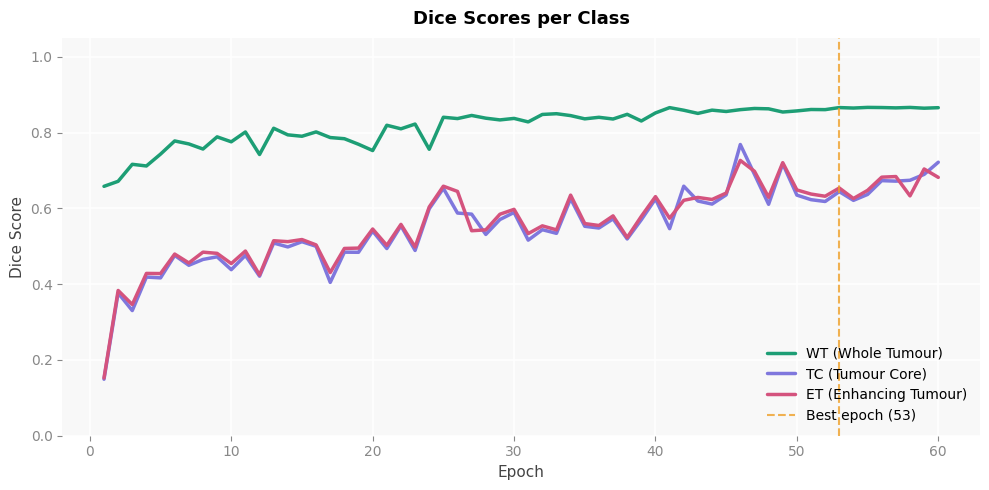

Saved: /kaggle/working/plots/dice_scores.png


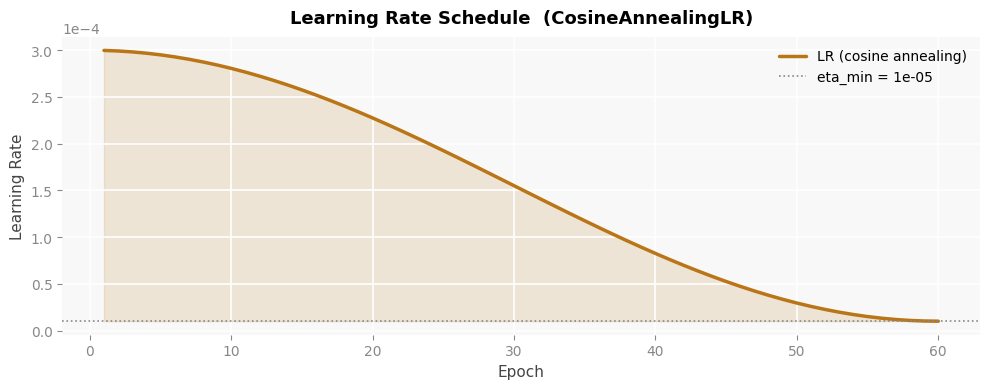

Saved: /kaggle/working/plots/lr_schedule.png


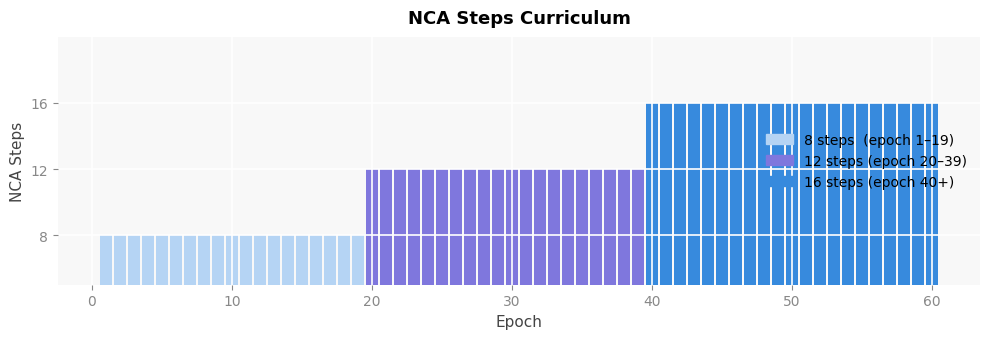

Saved: /kaggle/working/plots/nca_steps.png


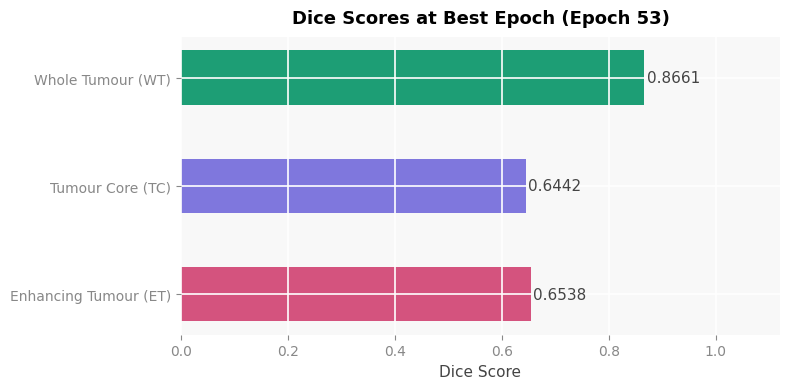

Saved: /kaggle/working/plots/best_epoch_bar.png


/tmp/ipykernel_57/1953658079.py:334: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


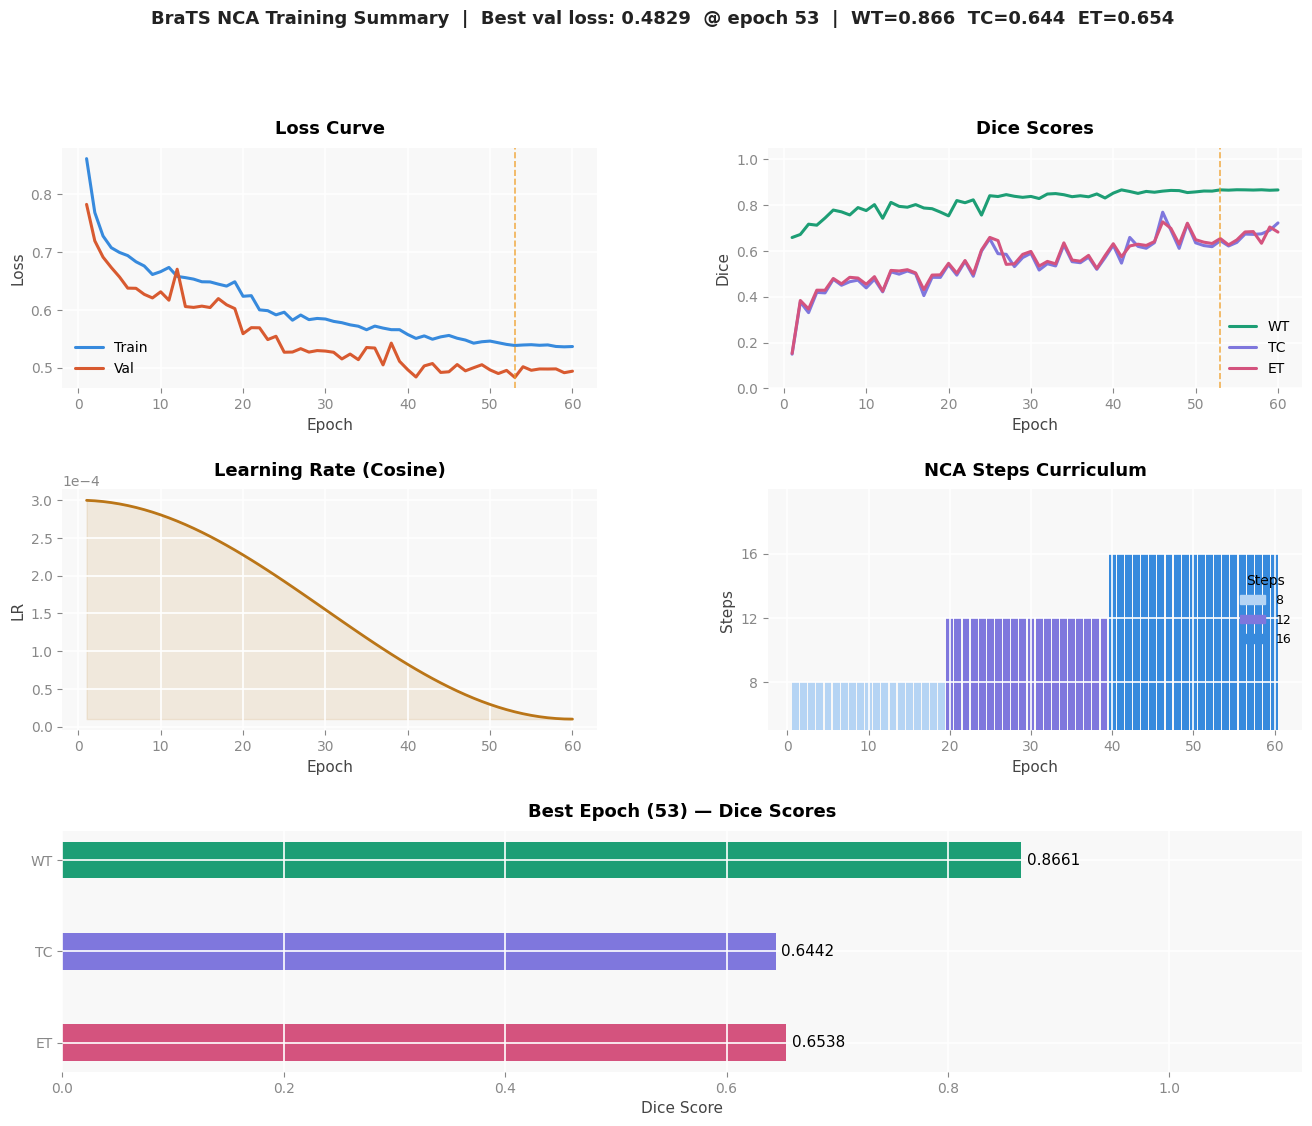

Saved: /kaggle/working/plots/training_dashboard.png
  TRAINING SUMMARY
  Total epochs         : 60
  Best epoch           : 53
  Best train loss      : 0.5381
  Best val loss        : 0.4829
  Final train loss     : 0.5363
  Final val loss       : 0.4936
------------------------------------------------------------
  Dice WT  @ best      : 0.8661  (max=0.8666)
  Dice TC  @ best      : 0.6442  (max=0.7686)
  Dice ET  @ best      : 0.6538  (max=0.7266)
  Mean Dice @ best     : 0.7214
------------------------------------------------------------
  NCA step transitions : 8 (ep 1-19)  →  12  →  16

All plots saved to: /kaggle/working/plots
Download via Kaggle Output panel on the right.


In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION CELL 1 — Imports & style setup
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import os

# Clean, publication-ready style
plt.rcParams.update({
    'figure.facecolor'    : 'white',
    'axes.facecolor'      : '#F8F8F8',
    'axes.grid'           : True,
    'grid.color'          : 'white',
    'grid.linewidth'      : 1.2,
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'axes.spines.left'    : False,
    'axes.spines.bottom'  : False,
    'axes.labelcolor'     : '#444444',
    'axes.titlesize'      : 13,
    'axes.titleweight'    : 'bold',
    'axes.titlepad'       : 10,
    'axes.labelsize'      : 11,
    'xtick.color'         : '#888888',
    'ytick.color'         : '#888888',
    'xtick.labelsize'     : 10,
    'ytick.labelsize'     : 10,
    'legend.frameon'      : False,
    'legend.fontsize'     : 10,
    'font.family'         : 'DejaVu Sans',
    'lines.linewidth'     : 2.2,
    'lines.solid_capstyle': 'round',
})

SAVE_DIR = '/kaggle/working/plots'
os.makedirs(SAVE_DIR, exist_ok=True)

# Color palette
C_TRAIN  = '#378ADD'   # blue
C_VAL    = '#D85A30'   # coral
C_WT     = '#1D9E75'   # teal
C_TC     = '#7F77DD'   # purple
C_ET     = '#D4537E'   # pink
C_LR     = '#BA7517'   # amber
C_STEPS  = ['#B5D4F4', '#7F77DD', '#378ADD']   # 8 / 12 / 16 steps
C_BEST   = '#EF9F27'   # best epoch marker

print("Visualization setup ready.")
print(f"Plots will be saved to: {SAVE_DIR}")


# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION CELL 2 — Plot 1: Loss Curve
# ═══════════════════════════════════════════════════════════════════════════════
def plot_loss(history, save_dir=SAVE_DIR):
    train_loss = history['train_loss']
    val_loss   = history['val_loss']
    epochs     = list(range(1, len(train_loss) + 1))

    best_epoch = int(np.argmin(val_loss)) + 1
    best_val   = min(val_loss)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(epochs, train_loss, color=C_TRAIN, label='Train loss',
            linewidth=2.5, alpha=0.9)
    ax.plot(epochs, val_loss,   color=C_VAL,   label='Val loss',
            linewidth=2.5, alpha=0.9)

    # Fill between
    ax.fill_between(epochs, train_loss, val_loss,
                    alpha=0.06, color=C_VAL)

    # Best epoch marker
    ax.axvline(best_epoch, color=C_BEST, linestyle='--', linewidth=1.5,
               alpha=0.8, label=f'Best epoch ({best_epoch})')
    ax.scatter([best_epoch], [best_val], color=C_BEST, s=80, zorder=5)
    ax.annotate(f'  val={best_val:.4f}',
                xy=(best_epoch, best_val),
                fontsize=9, color=C_BEST, va='bottom')

    ax.set_title('Training vs Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(loc='upper right')

    plt.tight_layout()
    path = os.path.join(save_dir, 'loss_curve.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

plot_loss(history)


# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION CELL 3 — Plot 2: Dice Scores (WT / TC / ET)
# ═══════════════════════════════════════════════════════════════════════════════
def plot_dice(history, save_dir=SAVE_DIR):
    epochs = list(range(1, len(history['dice_wt']) + 1))
    best_epoch = int(np.argmin(history['val_loss'])) + 1

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(epochs, history['dice_wt'], color=C_WT,  label='WT (Whole Tumour)',    linewidth=2.5)
    ax.plot(epochs, history['dice_tc'], color=C_TC,  label='TC (Tumour Core)',     linewidth=2.5)
    ax.plot(epochs, history['dice_et'], color=C_ET,  label='ET (Enhancing Tumour)',linewidth=2.5)

    ax.axvline(best_epoch, color=C_BEST, linestyle='--', linewidth=1.5,
               alpha=0.8, label=f'Best epoch ({best_epoch})')

    ax.set_ylim(0, 1.05)
    ax.set_title('Dice Scores per Class')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Dice Score')
    ax.legend(loc='lower right')

    plt.tight_layout()
    path = os.path.join(save_dir, 'dice_scores.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

plot_dice(history)


# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION CELL 4 — Plot 3: Learning Rate Schedule
# ═══════════════════════════════════════════════════════════════════════════════
def plot_lr(history, save_dir=SAVE_DIR,
            base_lr=3e-4, eta_min=1e-5, epochs=None):
    n = len(history['train_loss'])
    if epochs is None:
        epochs = n

    ep = list(range(1, n + 1))
    lr_vals = [eta_min + 0.5 * (base_lr - eta_min) *
               (1 + np.cos(np.pi * e / epochs))
               for e in ep]

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(ep, lr_vals, color=C_LR, linewidth=2.5, label='LR (cosine annealing)')
    ax.fill_between(ep, eta_min, lr_vals, alpha=0.15, color=C_LR)

    ax.axhline(eta_min, color='#888888', linestyle=':', linewidth=1.2,
               label=f'eta_min = {eta_min:.0e}')

    ax.set_title('Learning Rate Schedule  (CosineAnnealingLR)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    ax.legend()

    plt.tight_layout()
    path = os.path.join(save_dir, 'lr_schedule.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

plot_lr(history, epochs=EPOCHS)


# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION CELL 5 — Plot 4: NCA Steps Curriculum
# ═══════════════════════════════════════════════════════════════════════════════
def plot_nca_steps(history, save_dir=SAVE_DIR):
    steps  = history.get('nca_steps', [])
    if not steps:
        n = len(history['train_loss'])
        steps = [8 if e < 20 else 12 if e < 40 else 16
                 for e in range(1, n + 1)]

    epochs = list(range(1, len(steps) + 1))
    colors = [C_STEPS[0] if s == 8 else C_STEPS[1] if s == 12 else C_STEPS[2]
              for s in steps]

    fig, ax = plt.subplots(figsize=(10, 3.5))

    bars = ax.bar(epochs, steps, color=colors, width=0.85, edgecolor='none')

    legend_patches = [
        mpatches.Patch(color=C_STEPS[0], label='8 steps  (epoch 1–19)'),
        mpatches.Patch(color=C_STEPS[1], label='12 steps (epoch 20–39)'),
        mpatches.Patch(color=C_STEPS[2], label='16 steps (epoch 40+)'),
    ]
    ax.legend(handles=legend_patches, loc='center right')

    ax.set_yticks([8, 12, 16])
    ax.set_ylim(5, 20)
    ax.set_title('NCA Steps Curriculum')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('NCA Steps')

    plt.tight_layout()
    path = os.path.join(save_dir, 'nca_steps.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

plot_nca_steps(history)


# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION CELL 6 — Plot 5: Best Epoch Dice Bar Chart
# ═══════════════════════════════════════════════════════════════════════════════
def plot_best_epoch_bar(history, save_dir=SAVE_DIR):
    best_idx   = int(np.argmin(history['val_loss']))
    best_epoch = best_idx + 1

    wt = history['dice_wt'][best_idx]
    tc = history['dice_tc'][best_idx]
    et = history['dice_et'][best_idx]

    labels  = ['Whole Tumour (WT)', 'Tumour Core (TC)', 'Enhancing Tumour (ET)']
    values  = [wt, tc, et]
    colors  = [C_WT, C_TC, C_ET]

    fig, ax = plt.subplots(figsize=(8, 4))

    bars = ax.barh(labels, values, color=colors, height=0.5, edgecolor='none')

    for bar, val in zip(bars, values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=11, color='#444444')

    ax.set_xlim(0, 1.12)
    ax.set_title(f'Dice Scores at Best Epoch (Epoch {best_epoch})')
    ax.set_xlabel('Dice Score')
    ax.invert_yaxis()

    plt.tight_layout()
    path = os.path.join(save_dir, 'best_epoch_bar.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

plot_best_epoch_bar(history)


# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION CELL 7 — Plot 6: All-in-one Summary Dashboard
# ═══════════════════════════════════════════════════════════════════════════════
def plot_dashboard(history, save_dir=SAVE_DIR,
                   base_lr=3e-4, eta_min=1e-5, total_epochs=None):
    n          = len(history['train_loss'])
    total_epochs = total_epochs or n
    epochs     = list(range(1, n + 1))
    best_idx   = int(np.argmin(history['val_loss']))
    best_epoch = best_idx + 1

    steps = history.get('nca_steps',
            [8 if e < 20 else 12 if e < 40 else 16 for e in range(1, n + 1)])

    lr_vals = [eta_min + 0.5 * (base_lr - eta_min) *
               (1 + np.cos(np.pi * e / total_epochs))
               for e in epochs]

    fig = plt.figure(figsize=(16, 12))
    fig.patch.set_facecolor('white')
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.32)

    # ── 1. Loss curve ───────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, history['train_loss'], color=C_TRAIN, label='Train')
    ax1.plot(epochs, history['val_loss'],   color=C_VAL,   label='Val')
    ax1.axvline(best_epoch, color=C_BEST, linestyle='--', linewidth=1.2, alpha=0.8)
    ax1.set_title('Loss Curve')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend()

    # ── 2. Dice scores ──────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, history['dice_wt'], color=C_WT, label='WT')
    ax2.plot(epochs, history['dice_tc'], color=C_TC, label='TC')
    ax2.plot(epochs, history['dice_et'], color=C_ET, label='ET')
    ax2.axvline(best_epoch, color=C_BEST, linestyle='--', linewidth=1.2, alpha=0.8)
    ax2.set_ylim(0, 1.05)
    ax2.set_title('Dice Scores')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Dice')
    ax2.legend()

    # ── 3. LR schedule ──────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(epochs, lr_vals, color=C_LR, linewidth=2)
    ax3.fill_between(epochs, eta_min, lr_vals, alpha=0.12, color=C_LR)
    ax3.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    ax3.set_title('Learning Rate (Cosine)')
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('LR')

    # ── 4. NCA steps ────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    s_colors = [C_STEPS[0] if s == 8 else C_STEPS[1] if s == 12 else C_STEPS[2]
                for s in steps]
    ax4.bar(epochs, steps, color=s_colors, width=0.85, edgecolor='none')
    ax4.set_yticks([8, 12, 16])
    ax4.set_ylim(5, 20)
    ax4.set_title('NCA Steps Curriculum')
    ax4.set_xlabel('Epoch'); ax4.set_ylabel('Steps')
    leg4 = [mpatches.Patch(color=C_STEPS[0], label='8'),
            mpatches.Patch(color=C_STEPS[1], label='12'),
            mpatches.Patch(color=C_STEPS[2], label='16')]
    ax4.legend(handles=leg4, title='Steps', loc='center right', fontsize=9)

    # ── 5. Best epoch bar ───────────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, :])
    best_vals  = [history['dice_wt'][best_idx],
                  history['dice_tc'][best_idx],
                  history['dice_et'][best_idx]]
    best_lbls  = ['WT', 'TC', 'ET']
    best_cols  = [C_WT, C_TC, C_ET]
    bars = ax5.barh(best_lbls, best_vals, color=best_cols,
                    height=0.4, edgecolor='none')
    for bar, val in zip(bars, best_vals):
        ax5.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', fontsize=11)
    ax5.set_xlim(0, 1.12)
    ax5.set_title(f'Best Epoch ({best_epoch}) — Dice Scores')
    ax5.set_xlabel('Dice Score')
    ax5.invert_yaxis()

    # ── Suptitle with key numbers ───────────────────────────────────
    fig.suptitle(
        f'BraTS NCA Training Summary  |  '
        f'Best val loss: {history["val_loss"][best_idx]:.4f}  '
        f'@ epoch {best_epoch}  |  '
        f'WT={best_vals[0]:.3f}  TC={best_vals[1]:.3f}  ET={best_vals[2]:.3f}',
        fontsize=13, fontweight='bold', y=0.995, color='#222222'
    )

    plt.tight_layout()
    path = os.path.join(save_dir, 'training_dashboard.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

plot_dashboard(history, total_epochs=EPOCHS)


# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION CELL 8 — Print summary table
# ═══════════════════════════════════════════════════════════════════════════════
def print_summary(history):
    best_idx   = int(np.argmin(history['val_loss']))
    best_epoch = best_idx + 1
    n          = len(history['train_loss'])

    print("=" * 60)
    print("  TRAINING SUMMARY")
    print("=" * 60)
    print(f"  Total epochs         : {n}")
    print(f"  Best epoch           : {best_epoch}")
    print(f"  Best train loss      : {history['train_loss'][best_idx]:.4f}")
    print(f"  Best val loss        : {history['val_loss'][best_idx]:.4f}")
    print(f"  Final train loss     : {history['train_loss'][-1]:.4f}")
    print(f"  Final val loss       : {history['val_loss'][-1]:.4f}")
    print("-" * 60)
    print(f"  Dice WT  @ best      : {history['dice_wt'][best_idx]:.4f}  "
          f"(max={max(history['dice_wt']):.4f})")
    print(f"  Dice TC  @ best      : {history['dice_tc'][best_idx]:.4f}  "
          f"(max={max(history['dice_tc']):.4f})")
    print(f"  Dice ET  @ best      : {history['dice_et'][best_idx]:.4f}  "
          f"(max={max(history['dice_et']):.4f})")
    print(f"  Mean Dice @ best     : "
          f"{np.mean([history['dice_wt'][best_idx], history['dice_tc'][best_idx], history['dice_et'][best_idx]]):.4f}")
    print("-" * 60)
    nca = history.get('nca_steps', [])
    if nca:
        print(f"  NCA step transitions : "
              f"8 (ep 1-{next((i for i,s in enumerate(nca) if s>8), len(nca))})  →  "
              f"12  →  16")
    print("=" * 60)
    print(f"\nAll plots saved to: {SAVE_DIR}")
    print("Download via Kaggle Output panel on the right.")

print_summary(history)